In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split # Inte strikt nödvändigt men bra att ha med
np.random.seed(42) # Behåll seed för reproducerbarhet

# 1. Ladda data (Lösning för NameError: df is not defined)
df = pd.read_csv("health_study_dataset.csv")

# Dataförberedelse
df['smoker_num'] = df['smoker'].map({'Yes': 1, 'No': 0})

# 2. Skapa minst en klass (HealthAnalyzer)
class HealthAnalyzer:
    """
    En klass för att utföra grundläggande statistisk analys och
    beräkna deskriptiv statistik samt generera plots på hälsostudiedata.
    Använder den laddade datatramen vid initiering.
    """
    def __init__(self, dataframe):
        self.df = dataframe

    def calculate_descriptive_stats(self, columns):
        """
        Beräknar medelvärde, median, min och max för de angivna kolumnerna.

        :param columns: En lista med kolumnnamn (str) att analysera.
        :return: Ett DataFrame med deskriptiv statistik.
        """
        return self.df[columns].agg(['mean', 'median', 'min', 'max'])

    def plot_relationship(self, x_col, y_col, ax, title):
        """
        Skapar en scatter plot för att visa sambandet mellan två variabler.

        :param x_col: Namnet på x-variabeln.
        :param y_col: Namnet på y-variabeln.
        :param ax: Matplotlib axel-objekt.
        :param title: Diagrammets titel.
        """
        ax.scatter(self.df[x_col], self.df[y_col], alpha=0.6, color='gray')
        ax.set_title(title)
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(y_col.replace('_', ' ').title())

# 3. Instansiera klassen (Lösning för NameError: analyzer is not defined)
analyzer = HealthAnalyzer(df) 

# Använd klassmetoden för deskriptiv statistik
stat_kolumner = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']
deskriptiv_del2 = analyzer.calculate_descriptive_stats(stat_kolumner)

print("Deskriptiv statistik (via HealthAnalyzer-klassen):")
print(deskriptiv_del2)

Deskriptiv statistik (via HealthAnalyzer-klassen):
             age   weight     height  systolic_bp  cholesterol
mean    49.42625   73.413  171.84925   149.178625      4.92915
median  50.00000   73.200  171.35000   149.400000      4.97000
min     18.00000   33.700  144.40000   106.800000      2.50000
max     90.00000  114.400  200.40000   185.900000      7.88000


In [9]:
# Förbered data: X måste vara 2D (variabel) och Y 2D (mål)
X = df['age'].values.reshape(-1, 1) # Oberoende variabel (Ålder)
Y = df['systolic_bp'].values.reshape(-1, 1) # Beroende variabel (Systoliskt Blodtryck)

# Skapa och träna modellen (Här utförs matrisberäkningarna)
modell = LinearRegression()
modell.fit(X, Y)

# Gör förutsägelser för att rita regressionslinjen
Y_pred = modell.predict(X)

print("Resultat Linjär Regression (systolic_bp ~ age):")
print(f"Intercept ($\\beta_0$): {modell.intercept_[0]:.2f} mmHg")
print(f"Koefficient för Ålder ($\\beta_1$): {modell.coef_[0][0]:.3f} mmHg/år")

Resultat Linjär Regression (systolic_bp ~ age):
Intercept ($\beta_0$): 122.68 mmHg
Koefficient för Ålder ($\beta_1$): 0.536 mmHg/år


Scatter plot med regressionslinje sparad som 'del2_linjar_regression.png'.


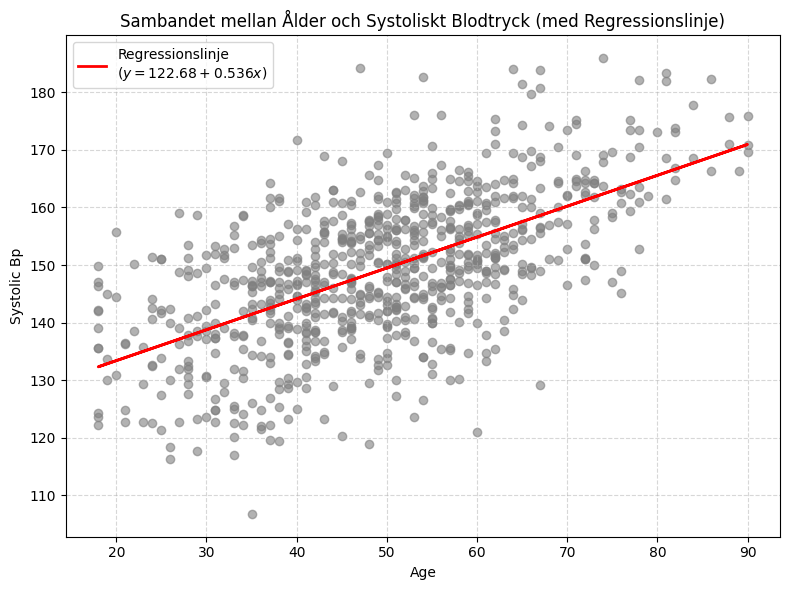

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Använd klassens metod för att skapa scatter-ploten
analyzer.plot_relationship(
    x_col='age',
    y_col='systolic_bp',
    ax=ax,
    title='Sambandet mellan Ålder och Systoliskt Blodtryck (med Regressionslinje)'
)

# Rita den beräknade regressionslinjen
ax.plot(
    X,
    Y_pred,
    color='red',
    linewidth=2,
    label=f'Regressionslinje\n($y={modell.intercept_[0]:.2f} + {modell.coef_[0][0]:.3f}x$)'
)
ax.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('del2_linjar_regression.png')

print("Scatter plot med regressionslinje sparad som 'del2_linjar_regression.png'.")

Jag har skrivit koden genom att skapa klassen , (det var jätte svart för mig, men jag hittat en bra sätt) HealthAnalyzer med metoder för statistik och visualisering. Linjär Algebra i Praktiken(Linjär Regression): jag använde sklearn.linear_model.LinearRegression för att modellera det linjära sambandet mellan Ålder och Systoliskt Blodtryck. Modellen löser problemet genom att använda matrisberäkningar (minsta kvadratmetoden) för att hitta de koefficienter som minimerar felet.Resultat: Koefficienten $0.536mmHg/år indikerar att blodtrycket i genomsnitt ökar med cirka $0.54 mmHg för varje levnadsår.
Slutsats: Grafen visar att trots den positiva trenden(röd linje) är punkterna spridda, vilket bekräftar att ålder bara är en av många faktorer som påverkar blodtrycket. Andra variabler, som vikt och rökning, skulle behöva inkluderas i en multipel linjär regressionsmodell för att få en bättre förutsägelse.